In [7]:
#!pip install requests pandas matplotlib

Fetching data for 600025.SS from 2020-01-01 to 2024-12-31...
Successfully fetched 1211 rows.
Final shape - X: (1186, 5), y: (1186,)

--- Generating price chart ---


/home/qili/miniconda3/envs/ai-sprint/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


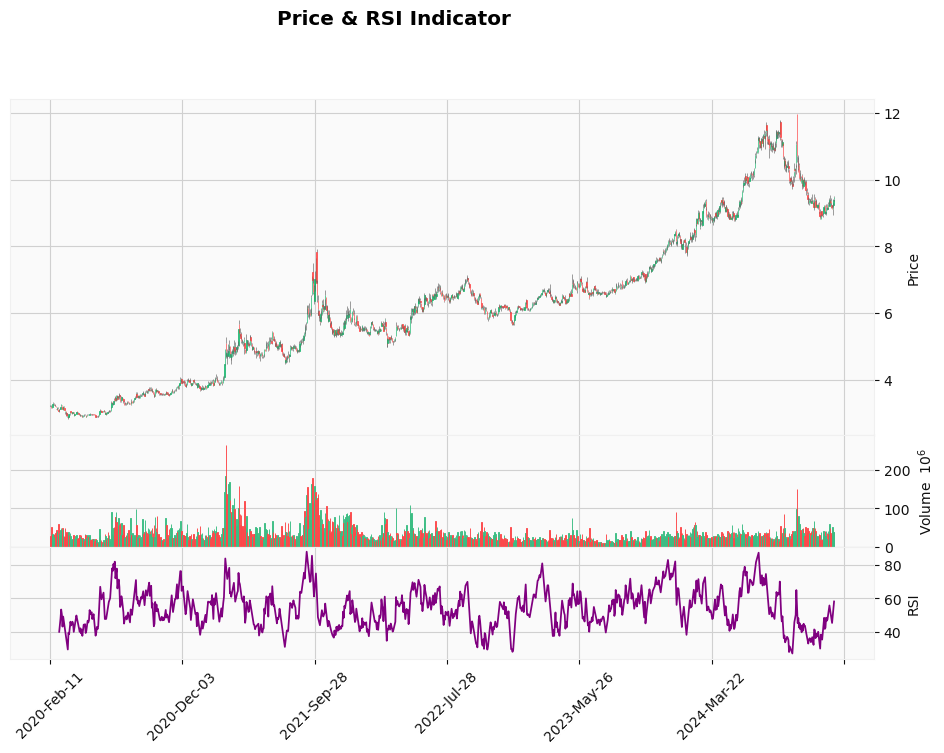


--- Starting Model Tuning ---

Testing RSI period = 10


/tmp/ipykernel_54787/1392254427.py:41: RuntimeWarning: divide by zero encountered in divide
  df_features['VolChange'] = np.append(np.nan, np.diff(volume) / volume[:-1])
/home/qili/miniconda3/envs/ai-sprint/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/qili/miniconda3/envs/ai-sprint/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/qili/miniconda3/envs/ai-sprint/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/qili/miniconda3/envs/ai-sprint/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
  File 

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [8]:
import pandas as pd
import numpy as np
import yfinance as yf
import talib
import mplfinance as mpf
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report


# ----------------------
# Custom Feature Engineering Class
# ----------------------
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, timeperiod=14):
        self.timeperiod = timeperiod

    def fit(self, X, y=None):
        return self

    def transform(self, df):
        df_features = df.copy()

        # Ensure 1D arrays for TA-Lib
        close = np.asarray(df_features['Close']).ravel()
        high = np.asarray(df_features['High']).ravel()
        low = np.asarray(df_features['Low']).ravel()
        volume = np.asarray(df_features['Volume']).ravel()

        # Technical indicators
        df_features['MA20'] = talib.SMA(close, timeperiod=20)
        df_features['ATR'] = talib.ATR(high, low, close, timeperiod=14)
        df_features['RSI'] = talib.RSI(close, timeperiod=self.timeperiod)
        df_features['CCI'] = talib.CCI(high, low, close, timeperiod=20)

        # Price & Volume changes
        df_features['PriceChange'] = np.append(np.nan, np.diff(close) / close[:-1])
        df_features['VolChange'] = np.append(np.nan, np.diff(volume) / volume[:-1])

        # Lagged features
        for lag in [1, 2, 3]:
            df_features[f'RSI_lag{lag}'] = df_features['RSI'].shift(lag)
            df_features[f'VolChange_lag{lag}'] = df_features['VolChange'].shift(lag)

        # Keep only calculated features
        feature_cols = [
            'MA20', 'ATR', 'RSI', 'CCI', 'PriceChange', 'VolChange',
            'RSI_lag1', 'RSI_lag2', 'RSI_lag3',
            'VolChange_lag1', 'VolChange_lag2', 'VolChange_lag3'
        ]
        return df_features[feature_cols]


# ----------------------
# Prepare Dataset using YFinance
# ----------------------
def prepare_full_dataset(ticker, start, end, max_feature_lookback=20, max_label_lookahead=3, max_lag=3):
    print(f"Fetching data for {ticker} from {start} to {end}...")

    try:
        # Download data and flatten columns to avoid MultiIndex issues
        df = yf.download(ticker, start=start, end=end, progress=False)
        if df.empty:
            print("Error: No data retrieved.")
            return None, None

        # Flatten column names and select only needed columns
        df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
        df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
        df.sort_index(inplace=True)

    except Exception as e:
        print(f"Error fetching data: {e}")
        return None, None

    print(f"Successfully fetched {len(df)} rows.")

    # --- Label: will price go up in next N days? ---
    close = np.asarray(df['Close']).ravel()
    future_return = pd.Series(close).pct_change(max_label_lookahead).shift(-max_label_lookahead).values
    df['future_return'] = future_return
    df['label'] = np.where(future_return > 0, 1, 0)

    # --- Check minimum data length ---
    required_min_len = max_feature_lookback + max_lag + max_label_lookahead
    if len(df) < required_min_len:
        print(f"Error: Need at least {required_min_len} rows, got {len(df)}.")
        return None, None

    # --- Find first valid row after indicator lookback ---
    temp_sma = talib.SMA(close, timeperiod=max_feature_lookback + max_lag)
    first_valid_idx = pd.Series(temp_sma, index=df.index).first_valid_index()
    if first_valid_idx is None:
        print("Error: Could not determine valid start index.")
        return None, None

    # --- Clean NaNs ---
    df_clean = df.loc[first_valid_idx:].dropna(subset=['future_return', 'label']).copy()

    # Split into raw features and labels
    y = df_clean['label'].astype(int)
    X_raw = df_clean.drop(columns=['label', 'future_return'])

    print(f"Final shape - X: {X_raw.shape}, y: {y.shape}")
    return X_raw, y


# ----------------------
# Visualization Function using mplfinance
# ----------------------
def plot_stock_with_indicators(df, rsi_period=14):
    """Plot price, volume, and RSI using mplfinance"""
    df_plot = df.copy()
    close = np.asarray(df_plot['Close']).ravel()
    df_plot['RSI'] = talib.RSI(close, timeperiod=rsi_period)

    # Add extra plots
    apds = [
        mpf.make_addplot(df_plot['RSI'], panel=2, color='purple', ylabel='RSI', secondary_y=False)
    ]

    # Plot
    mpf.plot(
        df_plot,
        type='candle',
        volume=True,
        addplot=apds,
        title='Price & RSI Indicator',
        style='yahoo',
        figsize=(12, 8),
        panel_ratios=(3, 1, 1)
    )


# ----------------------
# Main Execution
# ----------------------
if __name__ == "__main__":
    # --- Parameters ---
    TICKER = "600025.SS"  # Shanghai stock
    START_DATE = "2020-01-01"
    END_DATE = "2024-12-31"

    # --- Load data ---
    X_train_raw, y_train = prepare_full_dataset(
        ticker=TICKER,
        start=START_DATE,
        end=END_DATE
    )

    if X_train_raw is not None and y_train is not None:
        # Optional: Plot data
        print("\n--- Generating price chart ---")
        try:
            plot_stock_with_indicators(X_train_raw, rsi_period=14)
        except Exception as e:
            print(f"Plot skipped: {e}")

        print("\n--- Starting Model Tuning ---")
        best_score = -np.inf
        best_params = {}
        timeperiods = [10, 14, 20]

        # Model pipeline
        model_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(class_weight='balanced', random_state=42))
        ])

        param_grid = {
            'svm__C': [0.1, 1, 10],
            'svm__kernel': ['linear', 'rbf']
        }

        tscv = TimeSeriesSplit(n_splits=5)

        # Loop over different RSI periods
        for tp in timeperiods:
            print(f"\nTesting RSI period = {tp}")
            fe = FeatureEngineer(timeperiod=tp)
            X_feats = fe.transform(X_train_raw)

            # Align with labels and clean NaNs
            combined = pd.concat([X_feats, y_train], axis=1).dropna()
            if combined.empty:
                print("No valid data left, skipping.")
                continue

            X_clean = combined.drop(columns=['label'])
            y_clean = combined['label']

            # Grid search
            grid = GridSearchCV(
                estimator=model_pipeline,
                param_grid=param_grid,
                cv=tscv,
                scoring='f1',
                n_jobs=-1,
                verbose=0
            )
            grid.fit(X_clean, y_clean)

            print(f"Best F1: {grid.best_score_:.4f} | Params: {grid.best_params_}")

            if grid.best_score_ > best_score:
                best_score = grid.best_score_
                best_params = grid.best_params_.copy()
                best_params['rsi_timeperiod'] = tp

        # --- Final result ---
        print("\n--- Final Best Result ---")
        print(f"Best Parameters: {best_params}")
        print(f"Best F1 Score: {best_score:.4f}")

        # --- Final model evaluation ---
        best_tp = best_params['rsi_timeperiod']
        best_svm_args = {k.replace('svm__', ''): v for k, v in best_params.items() if k.startswith('svm__')}

        fe_final = FeatureEngineer(timeperiod=best_tp)
        X_final = fe_final.transform(X_train_raw)
        data_final = pd.concat([X_final, y_train], axis=1).dropna()

        final_model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(class_weight='balanced', random_state=42, **best_svm_args))
        ])
        final_model.fit(data_final.drop(columns=['label']), data_final['label'])
        preds = final_model.predict(data_final.drop(columns=['label']))

        print("\n--- Classification Report ---")
        print(classification_report(data_final['label'], preds))

    else:
        print("Failed to load data. Exiting.")